<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/notebooks/SentinelIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SentinelIQ V 0.2
# Statistical Observability Platform
# ============================================================

# This project simulates a banking observability pipeline
# capable of detecting infrastructure anomalies before
# they affect critical financial systems.
#
# Core Techniques Used:
# - EWMA Drift Detection
# - CUSUM Anomaly Detection
# - Persistence Scoring
# - Correlation Analysis
# - Bayesian Incident Prioritization
#
# Author: Shubhi Verma
# Environment: Google Colab / Jupyter Notebook
# ============================================================


# =========================
# STEP 1 — IMPORT LIBRARIES
# =========================

# Pandas -> Data manipulation
# NumPy -> Numerical operations
# PyPlot -> Dashboard visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import warnings
import os
import io

warnings.filterwarnings("ignore")
folders = [
    "src",
    "scripts",
    "data/raw",
    "data/processed",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [53]:
%%writefile scripts/generate_banking_logs.py

# ============================================================
# SentinelIQ V0.2
# Banking Log Generator
# ============================================================

# This script generates realistic structured banking logs
# for anomaly detection and observability experiments.
#
# Simulated Banking Services:
# - payment-api
# - auth-service
# - trading-engine
# - fraud-detection
# - notification-service
#
# Simulated Events:
# - normal requests
# - latency spikes
# - API timeouts
# - database failures
# - queue lag
# - infrastructure saturation
#
# Output:
# data/banking_logs.json
# data/banking_logs.csv
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import random
import json
import os
from datetime import datetime, timedelta
import io # Added this import


# =========================
# CREATE OUTPUT DIRECTORY
# =========================

os.makedirs("outputs", exist_ok=True)


# ============================================================
# CONFIGURATION
# ============================================================

TOTAL_LOGS = 5000

START_TIME = datetime(2026, 1, 1)

SERVICES = [
    "payment-api",
    "auth-service",
    "trading-engine",
    "fraud-detection",
    "notification-service",
    "portfolio-service",
    "investment-engine"
]

ENDPOINTS = [
    "/login",
    "/transfer",
    "/payment",
    "/trade",
    "/portfolio",
    "/kyc",
    "/withdrawal"
]

# Map services to their specific endpoints
SERVICE_ENDPOINTS_MAP = {
    "payment-api": ["/payment", "/transfer", "/withdrawal"],
    "auth-service": ["/login", "/kyc"],
    "trading-engine": ["/trade", "/payment", "/transfer"],
    "fraud-detection": ["/kyc", "/payment", "/transfer"],
    "notification-service": ["/login", "/transfer", "/payment"],
    "portfolio-service": ["/portfolio", "/trade"],
    "investment-engine": ["/trade", "/portfolio", "/withdrawal"]
}

# Map services to their base latencies
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}

REGIONS = [
    "India",
    "Singapore",
    "USA",
    "Germany",
    "UAE"
]

STATUS_TYPES = [
    "success",
    "timeout",
    "db_failure",
    "high_latency",
    "queue_delay"
]


# ============================================================
# GENERATE SINGLE LOG EVENT
# ============================================================

def generate_log_event(index):

    """
    Generates one structured banking log event.

    Simulates:
    - infrastructure metrics
    - service health
    - latency behavior
    - operational failures
    """

    # --------------------------------------------------------
    # Generate timestamp
    # --------------------------------------------------------

    timestamp = START_TIME + timedelta(
        seconds=index * 30
    )

    # --------------------------------------------------------
    # Randomly select banking service and its associated endpoint
    # --------------------------------------------------------

    service = random.choice(SERVICES)
    possible_endpoints = SERVICE_ENDPOINTS_MAP.get(service, ENDPOINTS) # Default to all endpoints if service not in map
    endpoint = random.choice(possible_endpoints)

    region = random.choice(REGIONS)

    # --------------------------------------------------------
    # Generate normal operational metrics with service-specific latency
    # --------------------------------------------------------

    base_latency = SERVICE_LATENCY_MAP.get(service, 120) # Default to 120 if service not in map
    latency_ms = int(
        np.random.normal(base_latency, 20) # Randomize around the base_latency
    )

    cpu_usage = round(
        np.random.normal(55, 8),
        2
    )

    memory_usage = round(
        np.random.normal(60, 10),
        2
    )

    queue_lag = max(
        0,
        int(np.random.normal(5, 2))
    )

    error_code = None

    status = "success"

    severity = "low"

    error_count = 0 # Initialize error_count

    # --------------------------------------------------------
    # Inject anomalies probabilistically
    # --------------------------------------------------------
    # Roughly 12% anomalous behavior
    # --------------------------------------------------------

    anomaly_probability = random.random()

    if anomaly_probability < 0.12:

        anomaly_type = random.choice(
            STATUS_TYPES[1:]
        )

        # =========================================
        # TIMEOUT EVENT
        # =========================================

        if anomaly_type == "timeout":

            latency_ms += random.randint(300, 700)

            cpu_usage += random.randint(10, 30)

            queue_lag += random.randint(10, 40)

            error_code = "TIMEOUT_ERROR"

            status = "timeout"

            severity = "critical"

            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # DATABASE FAILURE
        # =========================================

        elif anomaly_type == "db_failure":

            latency_ms += random.randint(200, 500)

            cpu_usage += random.randint(5, 20)

            memory_usage += random.randint(10, 20)

            error_code = "DB_CONNECTION_FAILURE"

            status = "db_failure"

            severity = "critical"

            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # HIGH LATENCY EVENT
        # =========================================

        elif anomaly_type == "high_latency":

            latency_ms += random.randint(150, 350)

            queue_lag += random.randint(5, 15)

            error_code = "LATENCY_SPIKE"

            status = "high_latency"

            severity = "medium"

            error_count = random.randint(2, 5) # Assign a numerical error count

        # =========================================
        # QUEUE DELAY EVENT
        # =========================================

        elif anomaly_type == "queue_delay":

            queue_lag += random.randint(20, 60)

            latency_ms += random.randint(80, 200)

            error_code = "QUEUE_BACKPRESSURE"

            status = "queue_delay"

            severity = "medium"

            error_count = random.randint(2, 5) # Assign a numerical error count

    # --------------------------------------------------------
    # Create structured log event
    # --------------------------------------------------------
    if latency_ms< 30
        latency_ms = 30

    log_event = {

        "timestamp": timestamp.isoformat(),

        "service": service,

        "endpoint": endpoint,

        "region": region,

        "latency_ms": latency_ms,

        "cpu_usage": round(cpu_usage, 2),

        "memory_usage": round(memory_usage, 2),

        "queue_lag": queue_lag,

        "status": status,

        "error_code": error_code,

        "severity": severity,

        "error_count": error_count # Add error_count to the log event
    }

    return log_event


# ============================================================
# GENERATE COMPLETE DATASET
# ============================================================

def generate_banking_logs(total_logs):

    """
    Generates complete banking observability dataset.
    """

    logs = []

    for i in range(total_logs):

        log = generate_log_event(i)

        logs.append(log)

    return logs


# ============================================================
# SAVE LOGS
# ============================================================

def save_logs(logs):

    """
    Saves logs in:
    - JSON format
    - CSV format
    """

    # --------------------------------------------------------
    # Save JSON logs
    # --------------------------------------------------------

    with open(
        "data/banking_logs.json",
        "w"
    ) as f:

        json.dump(
            logs,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # Save CSV logs
    # --------------------------------------------------------

    df = pd.DataFrame(logs)

    df.to_csv(
        "data/banking_logs.csv",
        index=False
    )

    # Capture the statistics output string
    stats_string = display_statistics(df)

    # Define the output file path
    output_file_path = 'outputs/logsStatistics.txt'

    # Ensure the 'outputs' directory exists
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

    # Write the captured output to the file
    with open(output_file_path, 'w') as f:
        f.write(stats_string)

    print(f"Log statistics saved to '{output_file_path}'") # Print confirmation here

    return df


# ============================================================
# DISPLAY SAMPLE STATISTICS
# ============================================================

def display_statistics(df):

    """
    Displays dataset overview and anomaly distribution.
    Returns the statistics as a string.
    """
    output_string = io.StringIO()

    output_string.write("\n================================================")
    output_string.write("\n SENTINELIQ LOG GENERATION COMPLETED ")
    output_string.write("\n================================================\n")
    output_string.write(f"\nTotal Logs Generated : {len(df)}\n")
    output_string.write("\nServices Monitored:")
    output_string.write(df['service'].value_counts().to_string())
    output_string.write("\n\nStatus Distribution:")
    output_string.write(df['status'].value_counts().to_string())
    output_string.write("\n\nSeverity Distribution:")
    output_string.write(df['severity'].value_counts().to_string())
    output_string.write("\n\nSample Logs:")
    output_string.write(df.head().to_string())

    # Print to stdout as well for immediate display
    print(output_string.getvalue())
    print("printed sample logs")
    return output_string.getvalue()


# ============================================================
# MAIN DATA GENERATION EXECUTION PIPELINE
# ============================================================

def main():

    print("\nGenerating banking observability logs...\n")

    logs = generate_banking_logs(TOTAL_LOGS)

    df = save_logs(logs)


    print("\nFiles Saved:\n")
    print(f"Banking logs in json saved to outputs/banking_logs.json ")
    print(f"Banking logs in csv format saved to outputs/banking_logs.csv ")
    print(f"Log statistics saved to outputs/logsStatistics.txt")
    print("\nLog generation completed successfully.\n")
    return df

Overwriting scripts/generate_banking_logs.py


In [28]:
%%writefile scripts/call_generate_banking_logs.py
import generate_banking_logs

if __name__ == "__main__":
    df = generate_banking_logs.main()
    print(df.head())


Overwriting scripts/call_generate_banking_logs.py


In [11]:
! python scripts/call_generate_banking_logs.py


Generating banking observability logs...


 SENTINELIQ LOG GENERATION COMPLETED 

Total Logs Generated : 5000

Services Monitored:service
fraud-detection         781
payment-api             734
portfolio-service       726
trading-engine          711
investment-engine       688
notification-service    684
auth-service            676

Status Distribution:status
success         4408
db_failure       162
timeout          148
high_latency     148
queue_delay      134

Severity Distribution:severity
low         4408
critical     310
medium       282

Sample Logs:             timestamp               service     endpoint     region  latency_ms  cpu_usage  memory_usage  queue_lag   status error_code severity  error_count
0  2026-01-01T00:00:00           payment-api  /withdrawal        UAE         163      50.46         55.20          5  success       None      low            0
1  2026-01-01T00:00:30  notification-service       /login    Germany          68      51.51         56.70          4  

In [37]:
%%writefile src/generate_banking_logs_metrics.py

# ============================================================
# STEP 3 — EWMA DRIFT DETECTION
# ============================================================

def apply_ewma_detection(df, alpha=0.3):

    """
    Applies EWMA anomaly detection.

    EWMA helps detect gradual operational drift
    before systems cross critical thresholds.

    Parameters:
    -----------
    df : pandas.DataFrame
        Banking observability dataset

    alpha : float
        EWMA smoothing factor
        typically between 0 and 1, which dictates how quickly the average adapts to new data
        Higher the value it reacts faster to recent changes

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with EWMA metrics

    threshold : float
        Dynamic anomaly threshold
    """

    # Compute EWMA latency trend
    df['ewma_latency'] = (
        round(df['latency_ms']
        .ewm(alpha=alpha)
        .mean(),2)
    )

    """
    e.g. Mean: 100 Std Dev: 10  Threshold: (100 + (2*10))= 120ms
    If the EWMA trend hits 125ms, the code flags it because it has moved significantly further than the usual "wiggle" room.
    """
    # Dynamic anomaly threshold
    threshold = (
        df['ewma_latency'].mean()
        +
        2 * df['ewma_latency'].std()
    )

    # Flag anomalous drift regions
    df['ewma_alert'] = (
        df['ewma_latency'] > threshold
    )

    print("EWMA detection completed.\n")

    return df, threshold


# ============================================================
# STEP 4 — CUSUM DETECTION
# ============================================================

def apply_cusum_detection(df, k=5):

    """
    Applies CUSUM detection.

    CUSUM identifies cumulative deviations
    from normal operational behavior.

    Useful for:
    - silent degradation
    - queue accumulation
    - sustained instability
    """

    target = df['latency_ms'].mean()

    cusum = [0]

    for x in df['latency_ms'][1:]:

        s = round(max(
            0,
            cusum[-1] + (x - target - k)
        ),2)

        cusum.append(s)

    df['cusum'] = cusum

    # Alert threshold
    df['cusum_alert'] = (
        df['cusum'] > 50
    )

    print("CUSUM detection completed.\n")

    return df


# ============================================================
# STEP 5 — PERSISTENCE SCORING
# ============================================================

def calculate_persistence_score(df):

    """
    Measures anomaly persistence duration.

    Persistent anomalies are treated as
    higher operational risks than isolated spikes.
    """

    # Combine anomaly signals
    df['combined_alert'] = (
        df['ewma_alert'] | df['cusum_alert']
    )

    persistence = []

    count = 0

    for val in df['combined_alert']:

        if val:
            count += 1
        else:
            count = 0

        persistence.append(count)

    df['persistence_score'] = persistence

    print("Persistence scoring completed.\n")

    return df


# ==================================
# STEP 6 — CORRELATION ANALYSIS
# ==================================

def generate_correlation_analysis(df):

    correlation = df[
        [
            'latency_ms',
            'error_count',
            'cpu_usage'
        ]
    ].corr().round(2)

    print("\nCorrelation Matrix:\n")
    print(correlation)

    return correlation


# ===========================================
# STEP 7 — BAYESIAN PRIORITIZATION
# ===========================================

def apply_bayesian_prioritization(df):
    import pandas
    df['incident_probability'] = (round(

        0.4 * (
            df['persistence_score'] / df['persistence_score'].max()
        )

        +

        0.3 * (
            df['error_count']/df['error_count'].max()
        )

        +

        0.3 * (
            df['cpu_usage']/df['cpu_usage'].max()
        ), 2)
    )

    df['priority'] = pandas.cut(

        df['incident_probability'],

        bins=[0, 0.3, 0.6, 1],

        labels=[
            'Low',
            'Medium',
            'Critical'
        ]
    )

    return df


Overwriting src/generate_banking_logs_metrics.py


In [31]:
%%writefile src/generate_analysis.py

# ==================================
# STEP 8 — EXECUTIVE DASHBOARD
# ==================================

def generate_dashboard(df, threshold):
    import matplotlib.pyplot as pyplot

    # Plot the latency data
    pyplot.figure(figsize=(14,6))

    pyplot.plot(
        df['timestamp'],
        df['latency_ms'],
        label='Latency'
    )

    pyplot.plot(
        df['timestamp'],
        df['ewma_latency'],
        label='EWMA'
    )

    pyplot.axhline(
        threshold,
        color='red',
        linestyle='--',
        label='Threshold'
    )

    pyplot.title(
        "SentinelIQ Banking System Monitoring"
    )

    pyplot.xlabel("Timestamp")

    pyplot.ylabel("Latency (ms)")

    pyplot.legend()

    pyplot.grid(True)

    pyplot.xticks(rotation=45)

    pyplot.savefig("outputs/latency_chart.png")

    pyplot.show()


# ==================================
# STEP 9 — EXECUTIVE SUMMARY
# ==================================

def generate_executive_summary(df):

    critical_count = (
        df['priority'] == 'Critical').sum()

    medium_count = (
        df['priority'] == 'Medium').sum()

    summary = f"""

    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------

    Critical Incidents : {critical_count}

    Medium Incidents   : {medium_count}

    Observations:
    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:
    Investigate payment processing systems
    and infrastructure resource utilization.

    """

    print(summary)

    return summary


Overwriting src/generate_analysis.py


In [39]:
%%writefile src/run_logs.py
import pandas as pd
import json

import generate_banking_logs_metrics as banking_utils
import generate_analysis as analysis_utils

# Load the banking_logs.csv file into a DataFrame
df = pd.read_csv('data/banking_logs.csv')

# Display the first 5 rows of the DataFrame
print(df.head())

print("Applying EWMA Detection...\n")
df, threshold = banking_utils.apply_ewma_detection(df)

print("Applying CUSUM Detection...\n")
df = banking_utils.apply_cusum_detection(df)

print("Calculating Persistence Scores...\n")
df = banking_utils.calculate_persistence_score(df)

print("Running Correlation Analysis...\n")
correlation = banking_utils.generate_correlation_analysis(df)

print("Applying Bayesian Prioritization...\n")
df = banking_utils.apply_bayesian_prioritization(df)

print("Generating Monitoring Dashboard...\n")
analysis_utils.generate_dashboard(df, threshold) Temporary comment

print("Generating Executive Summary...\n")
summary = analysis_utils.generate_executive_summary(df)

# Save outputs
df.to_csv(
        "outputs/sentineliq_results.csv",
        index=False
    )

print("Output with metrics saved to outputs/sentineliq_results.csv ")
with open('outputs/executive_summary.txt', 'w') as f:
      f.write(summary)

print("Executive summary saved to 'outputs/executive_summary.txt'")
print("\nPipeline Execution Completed.\n")

Overwriting src/run_logs.py


In [38]:
! python src/run_logs.py

             timestamp               service  ... severity error_count
0  2026-01-01T00:00:00           payment-api  ...      low           0
1  2026-01-01T00:00:30  notification-service  ...      low           0
2  2026-01-01T00:01:00       fraud-detection  ...      low           0
3  2026-01-01T00:01:30          auth-service  ...      low           0
4  2026-01-01T00:02:00        trading-engine  ...      low           0

[5 rows x 12 columns]
Applying EWMA Detection...

EWMA detection completed.

Applying CUSUM Detection...

CUSUM detection completed.

Calculating Persistence Scores...

Persistence scoring completed.

Running Correlation Analysis...


Correlation Matrix:

             latency_ms  error_count  cpu_usage
latency_ms         1.00         0.85       0.36
error_count        0.85         1.00       0.38
cpu_usage          0.36         0.38       1.00
Applying Bayesian Prioritization...

Generating Monitoring Dashboard...

Generating Executive Summary...



    SENTINELIQ OP

# Stage 2
Load data and do pre processing

In [57]:
import pandas as pd

df = pd.read_csv('outputs/sentineliq_results.csv')

print("Loaded 'outputs/sentineliq_results.csv' into 'results_df'.")
print(df.head())
count = df.duplicated().sum()
print(f'duplicate rows {count}')
print(df.info())

print(df.describe().T)

Loaded 'outputs/sentineliq_results.csv' into 'results_df'.
             timestamp               service     endpoint     region  \
0  2026-01-01T00:00:00           payment-api  /withdrawal        UAE   
1  2026-01-01T00:00:30  notification-service       /login    Germany   
2  2026-01-01T00:01:00       fraud-detection    /transfer        USA   
3  2026-01-01T00:01:30          auth-service         /kyc  Singapore   
4  2026-01-01T00:02:00        trading-engine       /trade        USA   

   latency_ms  cpu_usage  memory_usage  queue_lag   status error_code  \
0         163      50.46         55.20          5  success        NaN   
1          68      51.51         56.70          4  success        NaN   
2         213      56.72         71.00          5  success        NaN   
3          73      59.26         54.98          7  success        NaN   
4          94      51.06         61.08          8  success        NaN   

  severity  error_count  ewma_latency  ewma_alert  cusum  cusum_alert

In [55]:
desc = pd.DataFrame(index = list(df)) #create Rows with columns of orginal dataframe
desc['type'] = df.dtypes
desc['count'] = df.count()
desc['nunique'] = df.nunique()
desc['%unique'] = desc['nunique'] /len(df) * 100
desc['null'] = df.isnull().sum()
desc['%null'] = desc['null'] / len(df) * 100
desc = pd.concat([desc,df.describe().T.drop('count',axis=1)],axis=1)
desc.sort_values(by=['type','null']).style.background_gradient(cmap='YlOrBr')\
    .bar(subset=['mean'],color='green')\
    .bar(subset=['max'],color='red')\
    .bar(subset=['min'], color='pink').to_excel("outputs/Sentinel_preprocess.xlsx")

In [56]:
# Get a list of categorical columns in the dataframe
categorical_columns = df.select_dtypes(include=['object']).columns

# Check the unique values and their counts for each categorical column
for col in categorical_columns:
    print(f"Column: {col}")
    print("-" * 25)
    print(f"Unique values: {df[col].nunique()}")
    print(f"Unique values sample: {df[col].unique()[:10]}")  # Display a sample of unique values
    print("-" * 50)

Column: timestamp
-------------------------
Unique values: 5000
Unique values sample: ['2026-01-01T00:00:00' '2026-01-01T00:00:30' '2026-01-01T00:01:00'
 '2026-01-01T00:01:30' '2026-01-01T00:02:00' '2026-01-01T00:02:30'
 '2026-01-01T00:03:00' '2026-01-01T00:03:30' '2026-01-01T00:04:00'
 '2026-01-01T00:04:30']
--------------------------------------------------
Column: service
-------------------------
Unique values: 7
Unique values sample: ['payment-api' 'notification-service' 'fraud-detection' 'auth-service'
 'trading-engine' 'portfolio-service' 'investment-engine']
--------------------------------------------------
Column: endpoint
-------------------------
Unique values: 7
Unique values sample: ['/withdrawal' '/login' '/transfer' '/kyc' '/trade' '/portfolio'
 '/payment']
--------------------------------------------------
Column: region
-------------------------
Unique values: 5
Unique values sample: ['UAE' 'Germany' 'USA' 'Singapore' 'India']
-----------------------------------------

**Applying Isolation Forest for Anomaly Detection**
This section applies the Isolation Forest algorithm, an unsupervised learning method, to detect anomalies in the banking logs. Isolation Forest works by isolating anomalies rather than profiling normal data points, which makes it efficient and effective for high-dimensional datasets. The model will identify data points that are 'different' from the majority, flagging them as potential anomalies.

In [19]:
from sklearn.ensemble import IsolationForest


print("Applying Isolation Forest Detection...\n")

# Define features for Isolation Forest
features = df[
    [
        "latency_ms",
        "cpu_usage",
        "memory_usage",
        "queue_lag"
    ]
]

""""""""""""""""
# Initialize Isolation Forest model
model = IsolationForest(
    contamination=0.05, # Approximate proportion of anomalies in the dataset
    random_state=42
)

# Fit the model and make predictions
model.fit(features)
predictions = model.predict(features)

# Add Isolation Forest anomaly predictions to the DataFrame
df["ml_anomaly"] = predictions

# Convert predictions to a more intuitive anomaly flag (1 for anomaly, 0 for normal)
df['ml_anomaly'] = df['ml_anomaly'].apply(lambda x: 1 if x == -1 else 0)

print("Isolation Forest detection completed.\n")
"""

Loaded 'outputs/sentineliq_results.csv' into 'results_df'.
             timestamp               service     endpoint     region  \
0  2026-01-01T00:00:00           payment-api  /withdrawal        UAE   
1  2026-01-01T00:00:30  notification-service       /login    Germany   
2  2026-01-01T00:01:00       fraud-detection    /transfer        USA   
3  2026-01-01T00:01:30          auth-service         /kyc  Singapore   
4  2026-01-01T00:02:00        trading-engine       /trade        USA   

   latency_ms  cpu_usage  memory_usage  queue_lag   status error_code  \
0         163      50.46         55.20          5  success        NaN   
1          68      51.51         56.70          4  success        NaN   
2         213      56.72         71.00          5  success        NaN   
3          73      59.26         54.98          7  success        NaN   
4          94      51.06         61.08          8  success        NaN   

  severity  error_count  ewma_latency  ewma_alert    cusum  cusum_ale

'"\n# Initialize Isolation Forest model\nmodel = IsolationForest(\n    contamination=0.05, # Approximate proportion of anomalies in the dataset\n    random_state=42\n)\n\n# Fit the model and make predictions\nmodel.fit(features)\npredictions = model.predict(features)\n\n# Add Isolation Forest anomaly predictions to the DataFrame\ndf["ml_anomaly"] = predictions\n\n# Convert predictions to a more intuitive anomaly flag (1 for anomaly, 0 for normal)\ndf[\'ml_anomaly\'] = df[\'ml_anomaly\'].apply(lambda x: 1 if x == -1 else 0)\n\nprint("Isolation Forest detection completed.\n")\n'

### [Stage 3 EDA]

No numerical column is Null

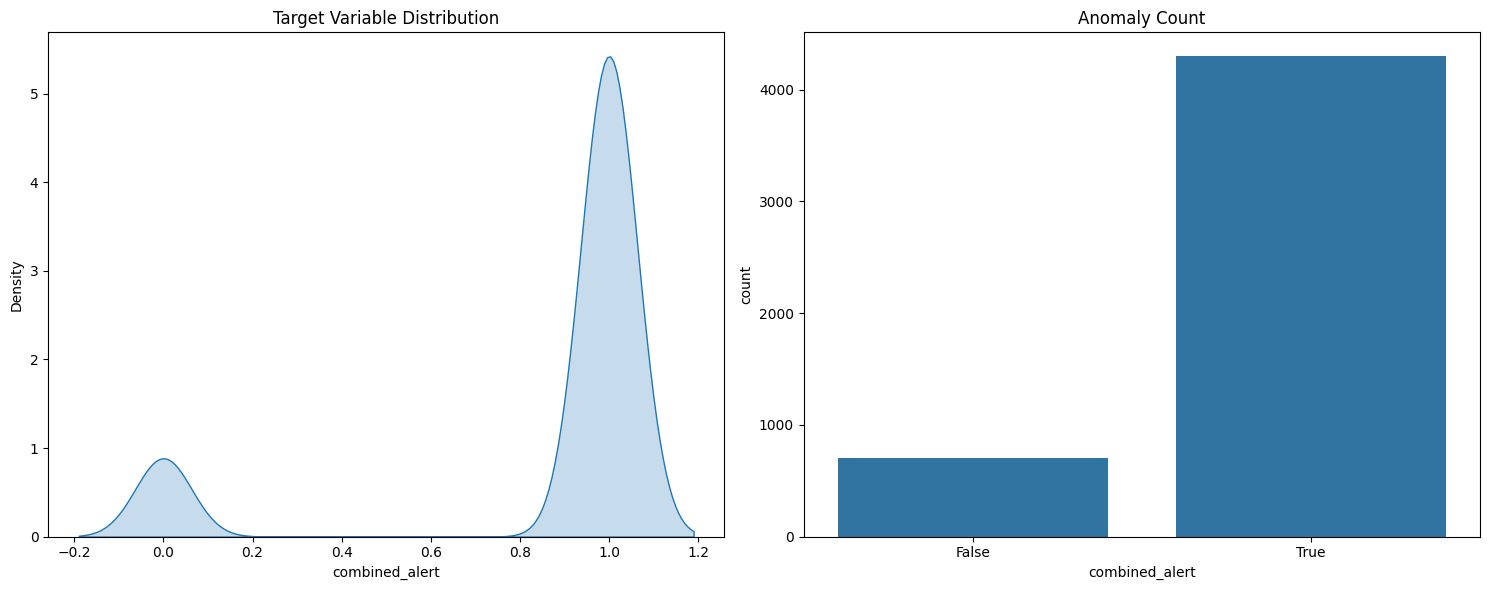

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Create a figure with 2 subplots in a horizontal row
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# A KDE (Kernel Density Estimate) Plot is used to visualize the distribution
#   of data, showing where your values are concentrated and where they are sparse

# KDE plot for the 'combined_alert' column (on the first subplot)
sns.kdeplot(df["combined_alert"], fill=True, ax=axes[0])
axes[0].set_title('Target Variable Distribution')

# Count plot for the 'combined_alert' column (on the second subplot)
sns.countplot(x='combined_alert', data=df, ax=axes[1])
axes[1].set_title('Anomaly Count')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

plt.savefig("KDE_Count_Plot.png", bbox_inches="tight")
plt.close()  # Closes the plot window to save memory

**Inspecting Isolation Forest Results**

Let's examine the first few rows of the DataFrame with the new ml_anomaly column and get a count of the detected anomalies. This will give us an initial idea of how many data points the Isolation Forest algorithm has identified as anomalous.


In [ ]:
print(df[['timestamp', 'latency_ms', 'cpu_usage', 'memory_usage', 'queue_lag', 'ml_anomaly']].head())
print(f"Total anomalies detected by Isolation Forest: {df['ml_anomaly'].sum()}")



             timestamp  latency_ms  cpu_usage  memory_usage  queue_lag  \
0  2026-01-01T00:00:00         115      54.66         72.37          2   
1  2026-01-01T00:00:30         136      47.40         66.51          3   
2  2026-01-01T00:01:00         132      57.43         51.03          3   
3  2026-01-01T00:01:30         142      58.05         55.53          4   
4  2026-01-01T00:02:00         117      68.43         61.82          6   

   ml_anomaly  
0           0  
1           0  
2           0  
3           0  
4           0  
Total anomalies detected by Isolation Forest: 250
